<a href="https://colab.research.google.com/github/wonderalexandre/MTLearn/blob/cfp%2Fscoring-regularization-examples/notebooks/experiments/CFP_soft_threshold_scoring_screws_filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/wonderalexandre/MTLearn/blob/run-notebooks-colab/notebooks/experiments/CFP_soft_threshold_scoring_screws_filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CFP soft-threshold scoring on the screws filtering dataset

This notebook runs one focused filtering example: learn the soft threshold `lambda_` of a single-attribute CFP scorer. The same simple scorer is also used in the segmentation notebook, so the two examples differ in the task loss and interpretation of the CFP output.

# Colab instalation

In [1]:
%cd /content
!rm -rf MTLearn
!git clone --recursive --branch cfp/scoring-regularization-examples https://github.com/wonderalexandre/MTLearn.git

%cd /content/MTLearn
!python -m pip install ".[notebooks]"

%cd /content

import sys, importlib
for name in list(sys.modules):
    if name == "mtlearn" or name.startswith("mtlearn."):
        del sys.modules[name]
sys.path = [p for p in sys.path if not p.startswith("/content/MTLearn")]
importlib.invalidate_caches()

/content
Cloning into 'MTLearn'...
remote: Enumerating objects: 945, done.
remote: Counting objects: 100% (531/531), done.
remote: Compressing objects: 100% (305/305), done.
remote: Total 945 (delta 250), reused 446 (delta 211), pack-reused 414 (from 1)
Receiving objects: 100% (945/945), 62.66 MiB | 32.94 MiB/s, done.
Resolving deltas: 100% (431/431), done.
Submodule 'external/MorphologicalAttributeFilters' (https://github.com/wonderalexandre/MorphologicalAttributeFilters) registered for path 'external/MorphologicalAttributeFilters'
Cloning into '/content/MTLearn/external/MorphologicalAttributeFilters'...
remote: Enumerating objects: 2975, done.        
remote: Counting objects: 100% (144/144), done.        
remote: Compressing objects: 100% (105/105), done.        
remote: Total 2975 (delta 49), reused 52 (delta 38), pack-reused 2831 (from 1)        
Receiving objects: 100% (2975/2975), 36.93 MiB | 32.94 MiB/s, done.
Resolving deltas: 100% (2104/2104), done.
Submodule path 'external/M

## Setup

Resolve the local checkout, import the libraries, fix the random seed, and choose the available device.

In [2]:
#!pip install mtlearn

import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import mtlearn
from mtlearn import morphology
from mtlearn.layers import ConnectedFilterPreprocessingLayer
from mtlearn.layers.cfp import ScoringModel
import mtlearn.layers.cfp as cfp

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
generator = torch.Generator().manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

device: cuda


## Experiment configuration

The target is a hard circularity filter on a min-tree. The learnable CFP scorer uses the same attribute and replaces the hard threshold with a sigmoid gate.

In [3]:
DATASET_NAME = "screws_segmentation"
NUM_ROWS = 256
NUM_COLS = 256
BATCH_SIZE = 8
OUTPUT_SCALE = 255.0

TARGET_TREE_TYPE = "min-tree"
TARGET_TREE_ENUM = morphology.TreeType.MIN_TREE
TARGET_ATTRIBUTE = morphology.Attribute.CIRCULARITY
TARGET_ATTRIBUTE_TYPE = morphology.AttributeType.CIRCULARITY
TARGET_THRESHOLD_ORIGINAL = 0.6

FILTER_KEY = "min_circularity_soft_threshold"
INITIAL_LAMBDA = 0.0
SCORE_SHARPNESS = 20.0
CLAMP_LOGIT = 12.0
LEARNING_RATE = 0.01
NUM_EPOCHS = 100
REPORT_EPOCHS = {1, 5, 10, 20, 50, 100}

config = {
    "task": "filtering",
    "tree": TARGET_TREE_TYPE,
    "attribute": TARGET_ATTRIBUTE.name,
    "target_threshold_original": TARGET_THRESHOLD_ORIGINAL,
    "scoring": "single_attribute_soft_threshold",
    "initial_lambda": INITIAL_LAMBDA,
    "score_sharpness": SCORE_SHARPNESS,
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
}
display(pd.DataFrame([config]))

,task,tree,attribute,target_threshold_original,scoring,initial_lambda,score_sharpness,learning_rate,num_epochs
0,filtering,min-tree,CIRCULARITY,0.6,single_attribute_soft_threshold,0.0,20.0,0.01,100


## Dataset

The dataset provides normalized input images and normalized targets. The target image is generated on the original `uint8` image by applying a hard attribute filter with `CIRCULARITY > 0.6`.

screws_segmentation: downloading to /content/dat/screws_segmentation
  downloaded   9% (1.0 MB / 10.5 MB)
  downloaded  19% (2.0 MB / 10.5 MB)
  downloaded  28% (3.0 MB / 10.5 MB)
  downloaded  38% (4.0 MB / 10.5 MB)
  downloaded  47% (5.0 MB / 10.5 MB)
  downloaded  57% (6.0 MB / 10.5 MB)
  downloaded  66% (7.0 MB / 10.5 MB)
  downloaded  76% (8.0 MB / 10.5 MB)
  downloaded  86% (9.0 MB / 10.5 MB)
  downloaded  95% (10.0 MB / 10.5 MB)
  downloaded 100% (10.5 MB / 10.5 MB)
  downloaded 10.5 MB
screws_segmentation: ready at /content/dat/screws_segmentation
trainset: 35
testset: 15


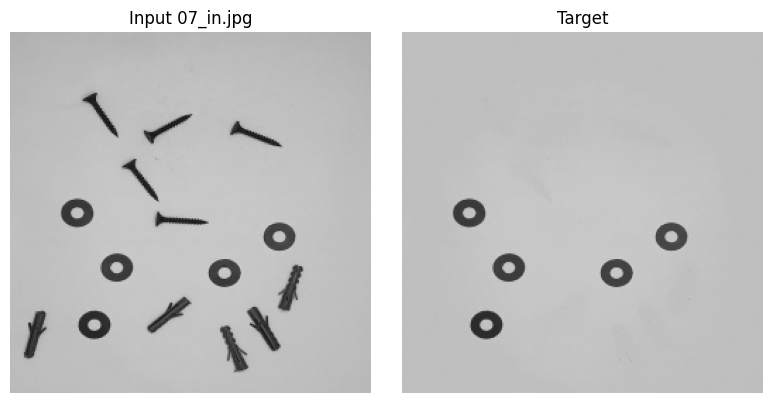

In [4]:
def make_attribute_filter_target(tree_type, attr_type, threshold):
    def target_fn(img):
        img_u8 = np.asarray(img)
        if img_u8.ndim != 2:
            raise ValueError(f"Expected grayscale image (H, W), got shape={img_u8.shape}")
        if img_u8.dtype != np.uint8:
            img_u8 = np.clip(img_u8, 0, 255).astype(np.uint8)

        tree = morphology.build_tree(img_u8, tree_type)
        attr_values = morphology.compute_single_attribute(tree, attr_type)
        filters = morphology.create_attribute_filter(tree)
        return filters.filteringSubtractiveRule(attr_values > threshold)

    return target_fn


dir_name = str(mtlearn.data.ensure_dataset(DATASET_NAME))
dataset = mtlearn.datasets.GeneratedTargetImageDataset(
    root_dir=dir_name,
    num_rows=NUM_ROWS,
    num_cols=NUM_COLS,
    suffix_in="_in",
    grayscale=True,
    scale_in=True,
    scale_out=True,
    target_fn=make_attribute_filter_target(TARGET_TREE_TYPE, TARGET_ATTRIBUTE, TARGET_THRESHOLD_ORIGINAL),
)

trainset, testset = dataset.train_test_split(test_size=0.3, random_state=SEED)
print("trainset:", len(trainset))
print("testset:", len(testset))

image_in, image_target, name = trainset[0]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_in.squeeze().detach().numpy(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Input {name}")
axes[1].imshow(image_target.squeeze().detach().numpy(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Target")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

trainset = [(x.to(device), y.to(device), name) for x, y, name in trainset]
testset = [(x.to(device), y.to(device), name) for x, y, name in testset]
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=False,
    generator=generator,
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=False,
)

## Scoring model

This is the minimal custom scorer used by both notebooks. It learns one scalar parameter, `lambda_`, and applies `sigmoid(score_sharpness * (attribute - lambda_))` to normalized node attributes.

In [5]:
class SingleAttributeSoftThresholdScorer(ScoringModel):
    kind = "single_attribute_soft_threshold"

    def __init__(self, num_features: int, *, initial_lambda: float = 0.0):
        super().__init__()
        if int(num_features) != 1:
            raise ValueError("single_attribute_soft_threshold requires exactly one feature.")
        self.num_features = int(num_features)
        self.initial_lambda = float(initial_lambda)
        self.lambda_ = torch.nn.Parameter(torch.tensor(self.initial_lambda, dtype=torch.float32))

    def forward(self, features, tree_info=None, context=None, *, score_sharpness=None, clamp=None):
        if features.dim() != 2 or features.size(1) != self.num_features:
            raise ValueError(f"expected features with shape (num_nodes, {self.num_features}), got {tuple(features.shape)}")

        sharpness = 1.0 if score_sharpness is None else float(score_sharpness)
        lambda_value = self.lambda_.to(dtype=features.dtype, device=features.device)
        logits = sharpness * (features[:, 0] - lambda_value)
        if clamp is not None:
            logits = torch.clamp(logits, clamp[0], clamp[1])
        return torch.sigmoid(logits)

    def to_config(self):
        return {"kind": self.kind, "initial_lambda": self.initial_lambda}


def create_single_attribute_soft_threshold_scorer(*, num_features: int, initial_lambda: float = 0.0, **options):
    if options:
        names = ", ".join(sorted(options))
        raise ValueError(f"unsupported single_attribute_soft_threshold scoring options: {names}")
    return SingleAttributeSoftThresholdScorer(num_features, initial_lambda=initial_lambda)


if "single_attribute_soft_threshold" not in cfp.SCORING_MODEL_REGISTRY.registered_kinds():
    cfp.SCORING_MODEL_REGISTRY.register(
        "single_attribute_soft_threshold",
        create_single_attribute_soft_threshold_scorer,
    )

## CFP layer

The CFP layer builds min-trees, computes circularity attributes, normalizes them with dataset-level `dataset_minmax01` statistics, and reconstructs an image after applying the learnable soft-threshold scores.

In [6]:
SCORING_CONFIG = {
    "kind": "single_attribute_soft_threshold",
    "initial_lambda": INITIAL_LAMBDA,
}

cfp_layer = ConnectedFilterPreprocessingLayer(
    in_channels=1,
    filter_specs=[
        {
            "name": FILTER_KEY,
            "tree_type": TARGET_TREE_ENUM,
            "attributes": TARGET_ATTRIBUTE_TYPE,
            "score_sharpness": SCORE_SHARPNESS,
            "scoring": SCORING_CONFIG,
        }
    ],
    scale_mode="dataset_minmax01",
    device=device,
    clamp=CLAMP_LOGIT,
)

# Caching computes tree payloads and the raw-attribute min/max statistics.
trainloader_cached = cfp_layer.build_dataloader_cached(trainloader)
testloader_cached = cfp_layer.build_dataloader_cached_fixed_stats(
    testloader,
    index_offset=len(trainset),
)

print("scoring config:", cfp_layer.get_config()["filter_specs"][0]["scoring"])
print("parameter contract:", cfp_layer.get_parameter_contract())

scoring config: {'kind': 'single_attribute_soft_threshold', 'initial_lambda': 0.0}
parameter contract: {'weights': {}, 'biases': {}, 'scoring_models': {'min_circularity_soft_threshold': {'lambda_': []}}}


## Evaluation utilities

The projection utility reports the learned `lambda_` on the original attribute scale. The notebook does not estimate or report a separate normalized-parameter value.

In [7]:
def lambda_to_original_attribute_scale(layer, filter_key=FILTER_KEY, attr_type=TARGET_ATTRIBUTE_TYPE):
    if layer.scale_mode != "dataset_minmax01":
        raise NotImplementedError("This notebook projects lambda only for scale_mode='dataset_minmax01'.")

    scorer = layer._scoring_models[filter_key]
    spec = layer._spec_by_key[filter_key]
    stat_key = layer._stat_key(spec.tree_key, attr_type)
    stats = layer._ds_stats[stat_key]

    lambda_param = scorer.lambda_.detach()
    amin = stats["amin"].to(dtype=lambda_param.dtype, device=lambda_param.device)
    amax = stats["amax"].to(dtype=lambda_param.dtype, device=lambda_param.device)
    denom = torch.clamp(amax - amin, min=layer.eps)
    lambda_original = amin + lambda_param * denom
    return {
        "lambda_original_projection": float(lambda_original.detach().cpu()),
        "attribute_min": float(amin.detach().cpu()),
        "attribute_max": float(amax.detach().cpu()),
    }


def evaluate_filtering(layer, dataloader):
    was_training = layer.training
    layer.eval()
    totals = {
        "mse_cfp_vs_target": 0.0,
        "mse_input_vs_target": 0.0,
        "mse_cfp_vs_input": 0.0,
        "mae_cfp_vs_target": 0.0,
        "mae_input_vs_target": 0.0,
    }
    count = 0

    with torch.no_grad():
        for batch_inputs, targets in dataloader:
            inputs = batch_inputs[0] if isinstance(batch_inputs, (tuple, list)) else batch_inputs
            predictions = layer(batch_inputs) / OUTPUT_SCALE
            count += targets.numel()
            totals["mse_cfp_vs_target"] += torch.sum((predictions - targets) ** 2).item()
            totals["mse_input_vs_target"] += torch.sum((inputs - targets) ** 2).item()
            totals["mse_cfp_vs_input"] += torch.sum((predictions - inputs) ** 2).item()
            totals["mae_cfp_vs_target"] += torch.sum(torch.abs(predictions - targets)).item()
            totals["mae_input_vs_target"] += torch.sum(torch.abs(inputs - targets)).item()

    layer.train(was_training)
    return {key: value / count for key, value in totals.items()}

## Initial state

Before any optimizer update, `lambda_` is fixed by the explicit initial value. The table reports only the original-scale projection and task metrics.

In [8]:
initial_train = evaluate_filtering(cfp_layer, trainloader_cached)
initial_test = evaluate_filtering(cfp_layer, testloader_cached)
initial_report = lambda_to_original_attribute_scale(cfp_layer)
initial_report.update({f"train_{key}": value for key, value in initial_train.items()})
initial_report.update({f"test_{key}": value for key, value in initial_test.items()})

print("Before training: lambda_ starts from the configured initial value.")
display(pd.DataFrame([initial_report]))

Before training: lambda_ starts from the configured initial value.


,lambda_original_projection,attribute_min,attribute_max,train_mse_cfp_vs_target,train_mse_input_vs_target,train_mse_cfp_vs_input,train_mae_cfp_vs_target,train_mae_input_vs_target,test_mse_cfp_vs_target,test_mse_input_vs_target,test_mse_cfp_vs_input,test_mae_cfp_vs_target,test_mae_input_vs_target
0,0.0,0.0,1.0,0.005181,0.009831,0.000815,0.018715,0.024727,0.005214,0.009871,0.000807,0.018567,0.024569


## Training

The training loop uses fixed hyperparameters: the optimizer learning rate is constant and `score_sharpness` is constant. At each report epoch, the notebook shows the same held-out image: input, target, and CFP output.

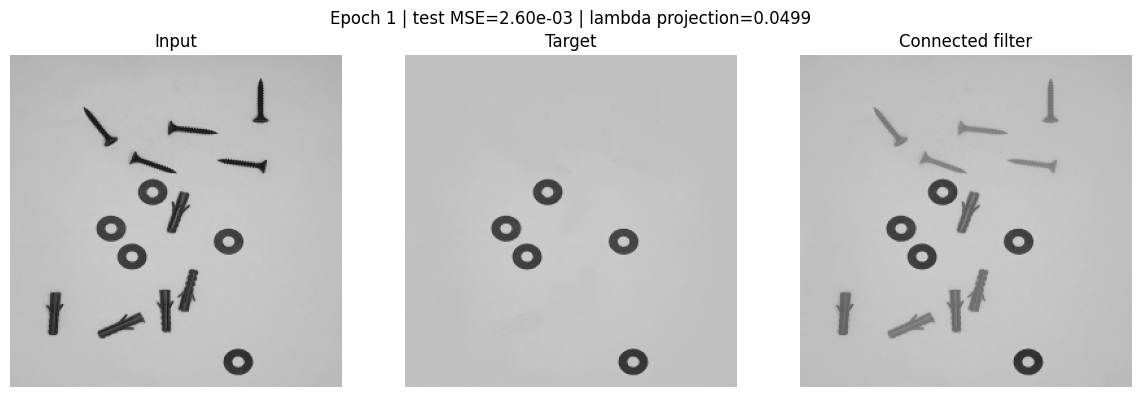

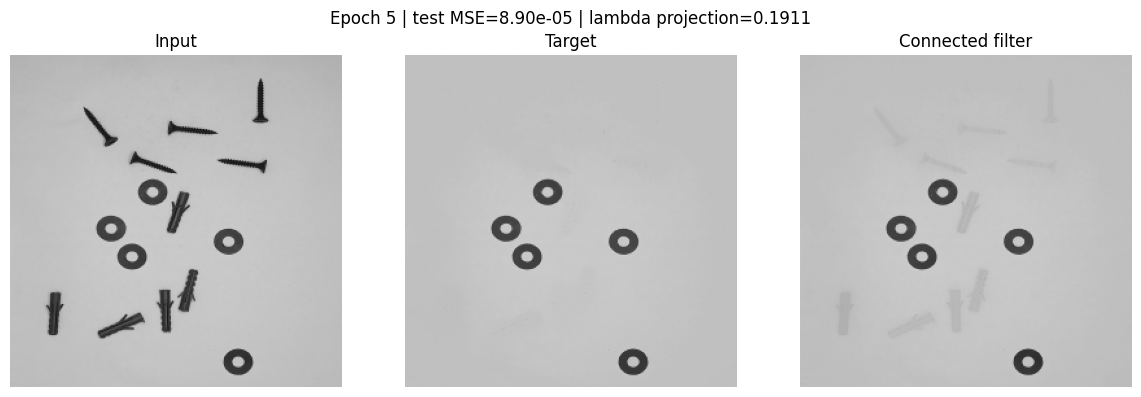

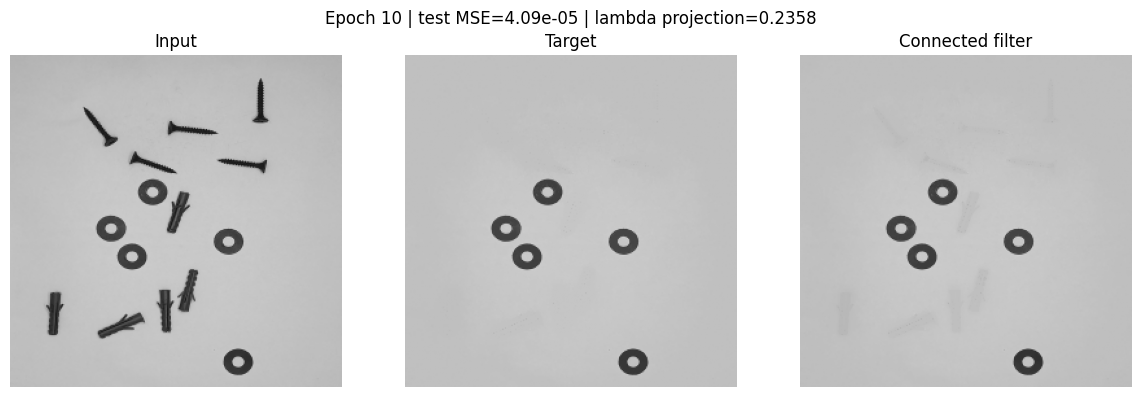

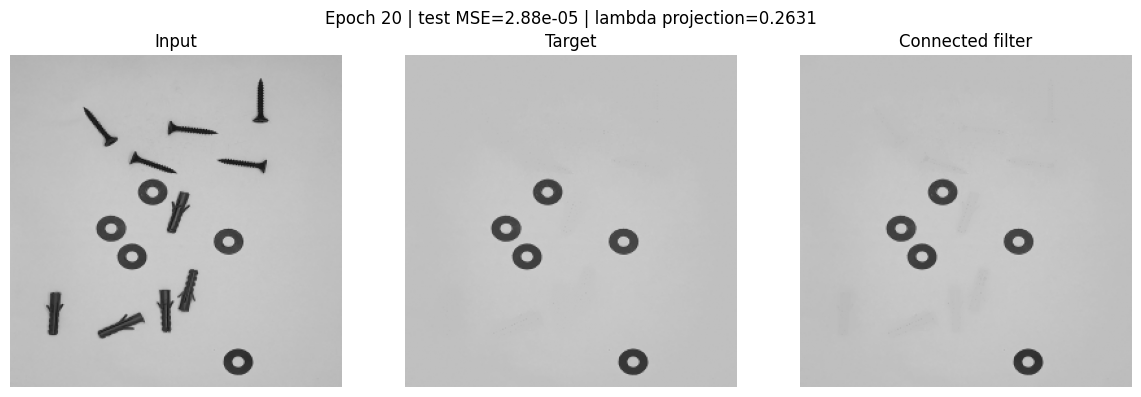

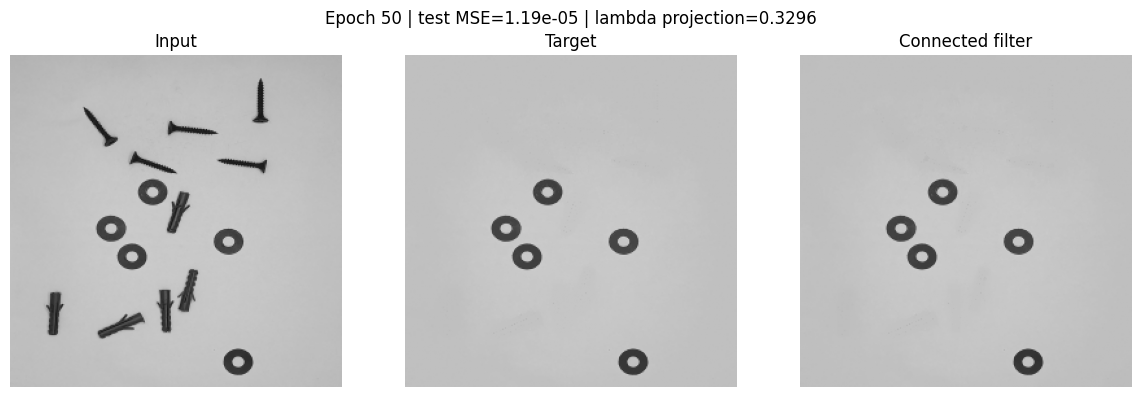

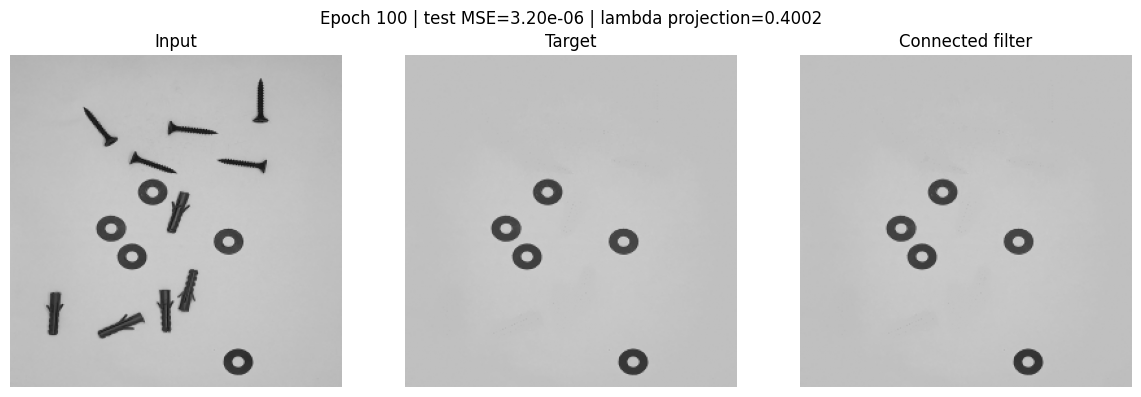

Training completed in 0.139 minutes.


In [9]:
loss_function = nn.MSELoss(reduction="mean")
optimizer = torch.optim.Adam(cfp_layer.parameters(), lr=LEARNING_RATE, weight_decay=0.0)
train_losses = []
report_rows = []
start = time.time()

viz_inputs, viz_targets = next(iter(testloader_cached))
viz_images = viz_inputs[0] if isinstance(viz_inputs, (tuple, list)) else viz_inputs

cfp_layer.train()
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss = 0.0
    last_grad_lambda = None

    for batch_inputs, targets in trainloader_cached:
        predictions = cfp_layer(batch_inputs) / OUTPUT_SCALE
        loss = loss_function(predictions, targets)

        optimizer.zero_grad()
        loss.backward()
        scorer = cfp_layer._scoring_models[FILTER_KEY]
        if scorer.lambda_.grad is not None:
            last_grad_lambda = float(scorer.lambda_.grad.detach().cpu())
        torch.nn.utils.clip_grad_norm_(cfp_layer.parameters(), max_norm=5.0)
        optimizer.step()

        epoch_loss += loss.item()

    train_epoch_loss = epoch_loss / len(trainloader_cached)
    train_losses.append(train_epoch_loss)

    if epoch in REPORT_EPOCHS:
        train_metrics = evaluate_filtering(cfp_layer, trainloader_cached)
        test_metrics = evaluate_filtering(cfp_layer, testloader_cached)
        row = lambda_to_original_attribute_scale(cfp_layer)
        row.update(
            {
                "epoch": epoch,
                "train_epoch_mse": train_epoch_loss,
                "learning_rate": LEARNING_RATE,
                "grad_lambda_last_batch": last_grad_lambda,
            }
        )
        row.update({f"train_{key}": value for key, value in train_metrics.items()})
        row.update({f"test_{key}": value for key, value in test_metrics.items()})
        report_rows.append(row)

        was_training = cfp_layer.training
        cfp_layer.eval()
        with torch.no_grad():
            viz_prediction = cfp_layer(viz_inputs) / OUTPUT_SCALE
        cfp_layer.train(was_training)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(viz_images[0, 0].detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[0].set_title("Input")
        axes[1].imshow(viz_targets[0, 0].detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[1].set_title("Target")
        axes[2].imshow(viz_prediction[0, 0].detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[2].set_title("Connected filter")
        for axis in axes:
            axis.axis("off")
        fig.suptitle(
            f"Epoch {epoch} | test MSE={row['test_mse_cfp_vs_target']:.2e} | "
            f"lambda projection={row['lambda_original_projection']:.4f}"
        )
        plt.tight_layout()
        plt.show()

elapsed_minutes = (time.time() - start) / 60.0
trajectory = pd.DataFrame(report_rows)
print(f"Training completed in {elapsed_minutes:.3f} minutes.")

## Results

The table shows the fixed-learning-rate trajectory. The plotted horizontal line is the hard threshold used to generate the target; the learned curve is the original-scale projection of `lambda_`.

,epoch,lambda_original_projection,train_mse_cfp_vs_target,test_mse_cfp_vs_target,train_mse_input_vs_target,test_mse_input_vs_target,train_mae_cfp_vs_target,test_mae_cfp_vs_target,train_epoch_mse,learning_rate
0,1,0.049934,0.002604,0.002604,0.009831,0.009871,0.013890,0.013725,0.004130,0.01
1,5,0.191099,0.000140,0.000089,0.009831,0.009871,0.003830,0.003595,0.000167,0.01
2,10,0.235809,0.000077,0.000041,0.009831,0.009871,0.002772,0.002569,0.000075,0.01
3,20,0.263123,0.000055,0.000029,0.009831,0.009871,0.002344,0.002171,0.000052,0.01
4,50,0.329646,0.000021,0.000012,0.009831,0.009871,0.001564,0.001477,0.000020,0.01
5,100,0.400240,0.000005,0.000003,0.009831,0.009871,0.000848,0.000827,0.000005,0.01


Final report
lambda_ is learned by the custom scorer; this report projects it to the original attribute scale.


,lambda_original_projection,attribute_min,attribute_max,train_mse_cfp_vs_target,train_mse_input_vs_target,train_mse_cfp_vs_input,train_mae_cfp_vs_target,train_mae_input_vs_target,test_mse_cfp_vs_target,test_mse_input_vs_target,test_mse_cfp_vs_input,test_mae_cfp_vs_target,test_mae_input_vs_target
0,0.40024,0.0,1.0,0.000005,0.009831,0.009709,0.000848,0.024727,0.000003,0.009871,0.00977,0.000827,0.024569


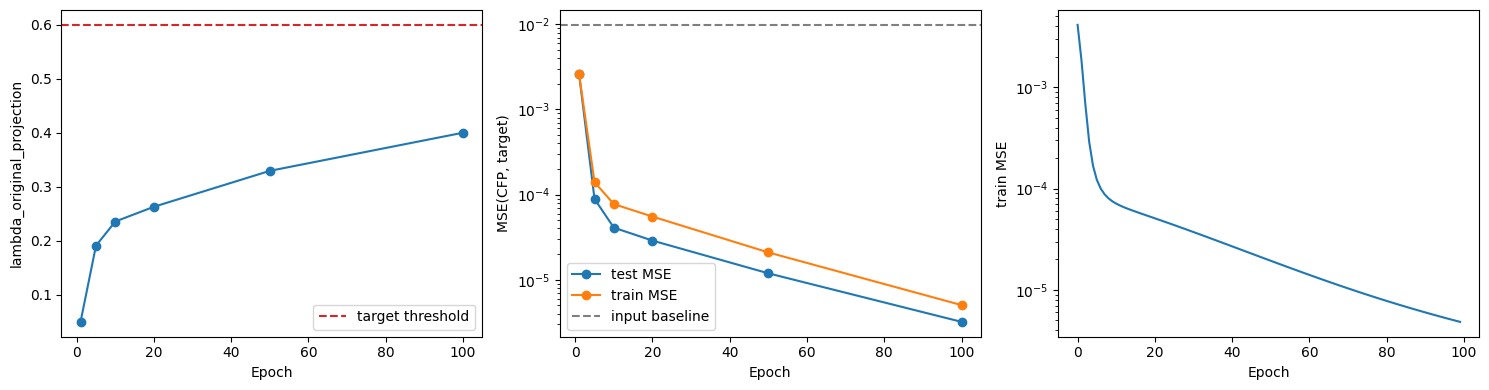

In [10]:
display_columns = [
    "epoch",
    "lambda_original_projection",
    "train_mse_cfp_vs_target",
    "test_mse_cfp_vs_target",
    "train_mse_input_vs_target",
    "test_mse_input_vs_target",
    "train_mae_cfp_vs_target",
    "test_mae_cfp_vs_target",
    "train_epoch_mse",
    "learning_rate",
]
display(trajectory[display_columns])

final_report = lambda_to_original_attribute_scale(cfp_layer)
final_report.update({f"train_{key}": value for key, value in evaluate_filtering(cfp_layer, trainloader_cached).items()})
final_report.update({f"test_{key}": value for key, value in evaluate_filtering(cfp_layer, testloader_cached).items()})

print("Final report")
print("lambda_ is learned by the custom scorer; this report projects it to the original attribute scale.")
display(pd.DataFrame([final_report]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(trajectory["epoch"], trajectory["lambda_original_projection"], marker="o")
axes[0].axhline(TARGET_THRESHOLD_ORIGINAL, color="tab:red", linestyle="--", label="target threshold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("lambda_original_projection")
axes[0].legend()

axes[1].semilogy(trajectory["epoch"], trajectory["test_mse_cfp_vs_target"], marker="o", label="test MSE")
axes[1].semilogy(trajectory["epoch"], trajectory["train_mse_cfp_vs_target"], marker="o", label="train MSE")
axes[1].axhline(final_report["test_mse_input_vs_target"], color="tab:gray", linestyle="--", label="input baseline")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE(CFP, target)")
axes[1].legend()

axes[2].semilogy(train_losses)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("train MSE")
plt.tight_layout()
plt.show()